In [96]:
import pandas as pd

#df = pd.read_parquet("/home/akroon/webdav/ASCOR-FMG-4394-AnNoBias (Projectfolder)/data/final_merged_dataset_for_analysis.parquet")

df = pd.read_parquet("/home/akroon/webdav/ASCOR-FMG-4394-AnNoBias (Projectfolder)/data/final_merged_dataset_for_analysis.parquet")
# Print original number of rows 

In [93]:
df['PolOrientation_cat']
df['normalized_party'].unique()

array([None, 'SP', 'GroenLinks-PvdA', 'Partij voor de Dieren', 'DENK',
       'VVD', 'PVV', 'Forum voor Democratie', 'JA21', 'Volt', 'D66',
       'CDA', 'ChristenUnie', 'Nieuw Sociaal Contract', 'SGP'],
      dtype=object)

In [ ]:
# Tailored instructions only reduce negative reactions when sources are visible — and mainly among those likely to vote. Unlikely voters remain relatively unaffected by any intervention.

In [94]:
df['instruction_type'].value_counts()

instruction_type
general instructions     48792
no instructions          47865
tailored instructions    46443
Name: count, dtype: int64

In [75]:
df[['normalized_party', 'full_text', 'vote_likelihood_score']].isnull().sum()

normalized_party         13487
full_text                37011
vote_likelihood_score    13487
dtype: int64

In [67]:
#df[ df['Both_Attention_Fail'] == 1 ]

In [77]:
def create_dsc_groups(data):
    median_dsc = data['dsc'].median()
    data['dsc_group'] = pd.cut(
        data['dsc'],
        bins=[-float('inf'), median_dsc, float('inf')],
        labels=['Low Bias', 'High Bias']
    )
    return data

In [97]:
import os
import pandas as pd
import statsmodels.formula.api as smf

# === Step 1: Fit Stepwise Mixed-Effects Models ===
def fit_stepwise_models(data, variable_name):
    filtered_data = data[data['variable'] == variable_name].copy()
    filtered_data['instruction_type'] = pd.Categorical(
        filtered_data['instruction_type'],
        categories=['no instructions', 'general instructions', 'tailored instructions'],
        ordered=True
    )

    formulas = [
        "value_scaled ~ Male + Age + source_shown + instruction_type + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown + instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown + instruction_type + vote_likelihood_score + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * dsc + instruction_type + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown * vote_likelihood_score + instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group",
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * instruction_type + dsc + negative_stance + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + Ideology_Group"
    ]
    return [smf.mixedlm(f, data=filtered_data, groups=filtered_data["uid"]).fit() for f in formulas]

# === Step 2: Rename predictors for display ===
def rename_predictors(predictors):
    return {
        'Intercept': 'Intercept',
        'instruction_type[T.general instructions]': 'General Instructions',
        'instruction_type[T.tailored instructions]': 'Tailored Instructions',
        'Edu_binary': 'Higher Educated',
        'Male': 'Male',
        'Age': 'Age',
        'source_shown': 'Source Shown',
        'vote_likelihood_score': 'Ideological Congruence',
        'dsc': 'Implicit Bias',
        'negative_stance': 'Negative Stance',
        'ImportIssue_1_numeric': 'Import Issue',
        'KnowIssue_1_numeric': 'Knowledge Issue',
        'AttitudeExtr2_combined': 'Attitude (Combined)',
        'Werk_binair': 'Employment',
        'Etniciteit_binair': 'Ethnicity',
        'Ideology_Group': 'Ideology',
        'source_shown:vote_likelihood_score': 'Source × Ideological Congruence',
        'vote_likelihood_score:dsc': 'Ideological Congruence × Bias',
        'vote_likelihood_score:instruction_type[T.general instructions]': 'Ideol. Congruence × General Instr.',
        'vote_likelihood_score:instruction_type[T.tailored instructions]': 'Ideol. Congruence × Tailored Instr.',
        'Group Var': 'Group Variance'
    }

# === Step 3: Generate LaTeX table ===
def generate_latex_table_with_group_variance(models, predictors, rename_map, variable_name):
    sections = {
        'Main Effects': [
            'instruction_type[T.general instructions]',
            'instruction_type[T.tailored instructions]',
            'source_shown',
            'dsc'
        ],
        'H1: Effects of Ideological Congruence': [
            'vote_likelihood_score'
        ],
        'H2: Moderating Effects of Implicit Bias': [
            'vote_likelihood_score:dsc'
        ],
        'H3: Moderating Effects of Source Visibility': [
            'source_shown:vote_likelihood_score'
        ],
        'H4: Moderating Effects of Instruction Type': [
            'vote_likelihood_score:instruction_type[T.general instructions]',
            'vote_likelihood_score:instruction_type[T.tailored instructions]'
        ],
        'Control Variables': [
            'Ideology_Group', 'Male', 'Age', 'ImportIssue_1_numeric', 'KnowIssue_1_numeric',
            'AttitudeExtr2_combined', 'Edu_binary', 'Werk_binair', 'Etniciteit_binair',
            'negative_stance'
        ]
    }

    def format_coef(model, predictor, italic=False):
        if predictor in model.params.index:
            coef = model.params[predictor]
            se = model.bse[predictor]
            p = model.pvalues[predictor]
            val = f"{coef:.2f} ({se:.2f})"
            if p < 0.05:
                val = f"\\textbf{{{val}}}"
            if italic:
                val = f"\\textit{{{val}}}"
            return val
        return "--"

    table_rows = []

    for section_title, section_predictors in sections.items():
        table_rows.append([f"\\\\[-0.5ex]\n\\multicolumn{{{len(models)+1}}}{{l}}{{\\textbf{{{section_title}}}}} \\\\"])
        for predictor in section_predictors:
            name = rename_map.get(predictor, predictor)
            italic = (section_title == "Control Variables")
            if italic:
                name = f"\\textit{{{name}}}"
            row = [name] + [format_coef(m, predictor, italic=italic) for m in models]
            table_rows.append(row)

    def get_group_var(model):
        return model.cov_re.iloc[0, 0] if not model.cov_re.empty else float('nan')
    def get_icc(model):
        gv = get_group_var(model)
        rv = model.scale
        return gv / (gv + rv) if gv + rv > 0 else float('nan')

    table_rows.append(["\\hline"])
    table_rows.extend([
        ["Group Variance"] + [f"{get_group_var(m):.4f}" for m in models],
        ["ICC"] + [f"{get_icc(m):.4f}" for m in models],
        ["Log Likelihood"] + [f"{m.llf:.2f}" for m in models],
        ["N (Obs)"] + [f"{int(m.nobs)}" for m in models],
        ["N (Groups)"] + [f"{len(m.random_effects)}" if hasattr(m, "random_effects") else "NA" for m in models]
    ])

    escaped_varname = variable_name.replace('_', '\\_')
    latex_table = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        f"\\caption{{Stepwise Mixed-Effects Model Results for {escaped_varname}}}\n"
        f"\\label{{tab:{variable_name}}}\n"
        "\\resizebox{\\textwidth}{!}{%\n"
        f"\\begin{{tabular}}{{{'l' + 'c'*len(models)}}}\n"
        "\\hline\n"
        + " & ".join(["Predictor"] + [f"Model {i+1}" for i in range(len(models))]) + " \\\\\n"
        "\\hline\n"
        + "\n".join(row[0] if row[0].startswith("\\\\") else " & ".join(row) + " \\\\"
                 for row in table_rows) +
        "\n\\hline\n"
        "\\end{tabular}%\n"
        "}\n"
        "\\end{table}"
    )
    return latex_table

# === Step 4: Run models and save tables ===
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
output_dir = "/home/akroon/webdav/ASCOR-FMG-4394-AnNoBias (Projectfolder)/output/tables/"
os.makedirs(output_dir, exist_ok=True)

fitted_models = {}
rename_map = rename_predictors([])

for var in variables:
    try:
        print(f"\n--- Fitting models for: {var} ---")
        fitted_models[var] = fit_stepwise_models(df, var)

        latex_table = generate_latex_table_with_group_variance(
            fitted_models[var], list(rename_map.keys()), rename_map, var
        )

        print(latex_table)

        file_path = os.path.join(output_dir, f"{var.replace('.', '_')}_models.tex")
        with open(file_path, "w") as f:
            f.write(latex_table)
        print(f"✅ Table saved: {file_path}")
    except Exception as e:
        print(f"❌ Error with {var}: {e}")


--- Fitting models for: stellingen.misinformation ---
\begin{table}[ht]
\centering
\caption{Stepwise Mixed-Effects Model Results for stellingen.misinformation}
\label{tab:stellingen.misinformation}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc}
\hline
Predictor & Model 1 & Model 2 & Model 3 & Model 4 & Model 5 & Model 6 \\
\hline
\\[-0.5ex]
\multicolumn{7}{l}{\textbf{Main Effects}} \\
General Instructions & 0.03 (0.05) & 0.03 (0.05) & 0.03 (0.05) & 0.03 (0.05) & 0.03 (0.05) & -0.08 (0.06) \\
Tailored Instructions & 0.07 (0.05) & 0.07 (0.05) & 0.07 (0.05) & 0.07 (0.05) & 0.07 (0.05) & 0.02 (0.06) \\
Source Shown & 0.01 (0.04) & 0.01 (0.04) & 0.02 (0.04) & 0.02 (0.04) & \textbf{0.21 (0.05)} & 0.02 (0.04) \\
Implicit Bias & -- & \textbf{-0.12 (0.05)} & \textbf{-0.14 (0.05)} & -0.08 (0.06) & \textbf{-0.14 (0.05)} & \textbf{-0.14 (0.05)} \\
\\[-0.5ex]
\multicolumn{7}{l}{\textbf{H1: Effects of Ideological Congruence}} \\
Ideological Congruence & -- & -- & \textbf{-0.08 (0.01)} & \text

In [83]:
# ==== Interaction visualization utilities (MixedLM, statsmodels) ====
# - Fixed for pandas CategoricalDtype deprecations
# - Correct delta-method CIs using the FIXED-EFFECTS covariance block
# - Three plotters: continuous×binary, continuous×3-level, continuous×continuous
# - Optional partial-residual overlay

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from patsy import dmatrix
from scipy.stats import norm
from pandas.api.types import CategoricalDtype

# ---------- helpers ----------
def _typical_row(df: pd.DataFrame) -> dict:
    """Representative values for controls (means for numeric, ref/first level for categoricals, mode for objects)."""
    row = {}
    for c in df.columns:
        s = df[c]
        if pd.api.types.is_numeric_dtype(s):
            row[c] = float(s.mean())
        elif isinstance(s.dtype, CategoricalDtype):
            row[c] = s.cat.categories[0]
        else:
            # object/string/etc.: use mode if available, else first non-null
            mode = s.mode(dropna=True)
            row[c] = mode.iloc[0] if not mode.empty else s.dropna().iloc[0] if s.notna().any() else np.nan
    return row

def _align_categoricals_like(df_ref: pd.DataFrame, df_target: pd.DataFrame) -> pd.DataFrame:
    """Ensure categoricals in df_target have same dtype/categories/order as df_ref where columns overlap."""
    out = df_target.copy()
    for col in df_ref.columns.intersection(out.columns):
        if isinstance(df_ref[col].dtype, CategoricalDtype):
            out[col] = pd.Categorical(
                out[col],
                categories=df_ref[col].cat.categories,
                ordered=df_ref[col].cat.ordered
            )
    return out

def _predict_fe_ci(result, exog_df: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
    """
    Fixed-effects prediction + Wald CI for statsmodels MixedLMResults
    given a DataFrame of exog values (original columns, not the design matrix).
    """
    # RHS of the model formula
    formula = result.model.formula
    rhs = formula.split("~", 1)[1].strip()

    # Build design matrix using model’s original design info if present to keep contrasts consistent
    try:
        design_info = result.model.data.orig_exog.design_info
        X = dmatrix(design_info, exog_df, return_type="dataframe")
    except Exception:
        X = dmatrix(rhs, exog_df, return_type="dataframe")

    # Align to fixed-effect params only
    fe_idx = result.fe_params.index
    # If patsy created columns that the model dropped, this will KeyError—catch to help debug
    missing = [c for c in fe_idx if c not in X.columns]
    if missing:
        raise KeyError(f"Design matrix is missing columns required by the fitted model: {missing}")
    X = X[fe_idx]

    beta = result.fe_params.values

    # Subset covariance to FE block ONLY (prevents shape mismatch with variance components)
    V_full = result.cov_params()
    if not hasattr(V_full, "loc"):  # coerce to DataFrame if array
        V_full = pd.DataFrame(V_full, index=result.params.index, columns=result.params.index)
    V = V_full.loc[fe_idx, fe_idx]

    pred = X.values @ beta
    se = np.sqrt(np.einsum("ij,jk,ik->i", X.values, V.values, X.values))

    z = norm.ppf(1 - alpha/2.0)
    lower = pred - z * se
    upper = pred + z * se
    return pd.DataFrame({"fit": pred, "lower": lower, "upper": upper})

def _prepare_grid(df_like: pd.DataFrame, base_row: dict, x: str, x_vals, mods: dict) -> pd.DataFrame:
    """
    Create a DataFrame grid varying x over x_vals and setting moderators in mods.
    Other columns fixed at base_row. Ensures categorical dtypes match df_like.
    """
    rows = []
    for xv in x_vals:
        r = base_row.copy()
        r[x] = xv
        for k, v in mods.items():
            r[k] = v
        rows.append(r)
    grid = pd.DataFrame(rows)
    grid = _align_categoricals_like(df_like, grid)
    return grid

def _x_range(df: pd.DataFrame, x: str, lo=5, hi=95, points=50):
    x_min, x_max = np.nanpercentile(df[x], [lo, hi])
    # Handle degenerate range
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        x_min, x_max = df[x].min(), df[x].max()
    return np.linspace(x_min, x_max, points)

# ---------- plotters ----------
def plot_interaction_continuous_by_binary(result, df, x: str, moderator: str, x_points: int = 50, ax=None, labels=None):
    """
    Example: x='vote_likelihood_score', moderator='source_shown' (0/1).
    Draws two lines with 95% CI ribbons (fixed-effects predictions).
    """
    if ax is None:
        fig, ax = plt.subplots()

    # Build typical row from the same filtered data the model was fit on
    base = _typical_row(df)
    xs = _x_range(df, x, points=x_points)

    mod_levels = sorted(pd.unique(df[moderator].dropna()))
    if len(mod_levels) != 2:
        raise ValueError(f"Expected a binary moderator; got levels: {mod_levels}")

    if labels is None:
        labels = {mod_levels[0]: f"{moderator}={mod_levels[0]}",
                  mod_levels[1]: f"{moderator}={mod_levels[1]}"}

    for m in mod_levels:
        grid = _prepare_grid(df, base, x, xs, {moderator: m})
        pred = _predict_fe_ci(result, grid)
        ax.plot(xs, pred["fit"], label=labels[m])
        ax.fill_between(xs, pred["lower"], pred["upper"], alpha=0.15)

    ax.set_xlabel(x)
    ax.set_ylabel("Predicted value_scaled")
    ax.set_title(f"Interaction: {x} × {moderator}")
    ax.legend()
    plt.tight_layout()
    return ax

def plot_interaction_continuous_by_3level(result, df, x: str, moderator: str, x_points: int = 50, ax=None):
    """
    Example: x='vote_likelihood_score', moderator='instruction_type' with 3 ordered levels.
    """
    if ax is None:
        fig, ax = plt.subplots()

    base = _typical_row(df)
    xs = _x_range(df, x, points=x_points)

    if isinstance(df[moderator].dtype, CategoricalDtype):
        levels = list(df[moderator].cat.categories)
    else:
        levels = sorted(pd.unique(df[moderator].dropna()))
    if len(levels) < 2:
        raise ValueError(f"Moderator '{moderator}' must have 2+ levels; got {levels}")

    for lvl in levels:
        grid = _prepare_grid(df, base, x, xs, {moderator: lvl})
        pred = _predict_fe_ci(result, grid)
        ax.plot(xs, pred["fit"], label=str(lvl))
        ax.fill_between(xs, pred["lower"], pred["upper"], alpha=0.15)

    ax.set_xlabel(x)
    ax.set_ylabel("Predicted value_scaled")
    ax.set_title(f"Interaction: {x} × {moderator}")
    ax.legend(title=moderator)
    plt.tight_layout()
    return ax

def plot_interaction_continuous_by_continuous(result, df, x: str, moderator: str, x_points: int = 50, mod_levels=("low","mid","high"), ax=None):
    """
    Example: x='vote_likelihood_score', moderator='dsc'.
    Draw 3 lines at −1 SD, mean, +1 SD of moderator.
    """
    if ax is None:
        fig, ax = plt.subplots()

    base = _typical_row(df)
    xs = _x_range(df, x, points=x_points)

    m = df[moderator]
    m_mean, m_sd = float(m.mean()), float(m.std(ddof=0))
    mod_values = [m_mean - m_sd, m_mean, m_mean + m_sd]
    labels = dict(zip(mod_values, [f"{moderator} ({lab})" for lab in mod_levels]))

    for mv in mod_values:
        grid = _prepare_grid(df, base, x, xs, {moderator: mv})
        pred = _predict_fe_ci(result, grid)
        ax.plot(xs, pred["fit"], label=labels[mv])
        ax.fill_between(xs, pred["lower"], pred["upper"], alpha=0.15)

    ax.set_xlabel(x)
    ax.set_ylabel("Predicted value_scaled")
    ax.set_title(f"Interaction: {x} × {moderator}")
    ax.legend()
    plt.tight_layout()
    return ax

# ---------- optional: partial residuals overlay ----------
def add_partial_residuals(ax, result, df, x: str, moderator: str, bins: int = 3, point_size: int = 10, alpha: float = 0.25):
    """
    Approximate partial residuals for x: r + b_x * x_i,
    where r are residuals from a model w/out x (quick visualization).
    """
    rhs = result.model.formula.split("~", 1)[1]
    y = result.model.endog_names
    # remove any term that contains x (crude but effective for simple names)
    terms = [t.strip() for t in rhs.split("+")]
    terms_wo_x = [t for t in terms if x not in t]
    rhs_wo_x = " + ".join(t for t in terms_wo_x if t)

    m_wo = smf.mixedlm(f"{y} ~ {rhs_wo_x}", data=df, groups=df["uid"]).fit()

    # coefficient(s) for x: can be more than one if x is involved in interactions; keep the main effect if present
    if x in result.fe_params.index:
        bx = result.fe_params[x]
    else:
        # fall back: use any column that endswith x or contains ':x' (very heuristic)
        cand = [k for k in result.fe_params.index if k.endswith(f"[{x}]") or k == x]
        bx = result.fe_params[cand[0]] if cand else 0.0

    partial = m_wo.resid + bx * df[x]

    if pd.api.types.is_numeric_dtype(df[moderator]):
        cats = pd.qcut(df[moderator], q=bins, duplicates="drop").astype(str)
    else:
        cats = df[moderator].astype(str)

    for cat in sorted(pd.unique(cats)):
        mask = (cats == cat)
        ax.scatter(df.loc[mask, x], partial.loc[mask], s=point_size, alpha=alpha, label=f"partial • {cat}")

    ax.legend()
    return ax

<Axes: title={'center': 'Interaction: vote_likelihood_score × instruction_type'}, xlabel='vote_likelihood_score', ylabel='Predicted value_scaled'>

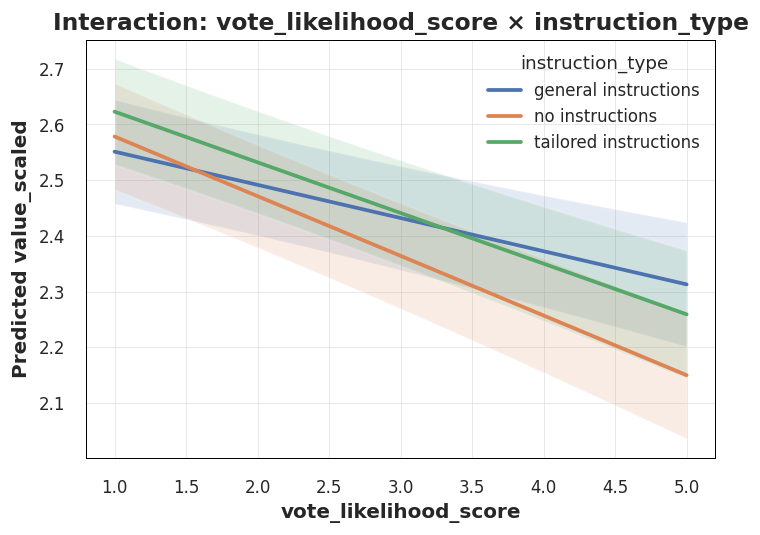

In [84]:
# using the dataset you used to fit the model that includes this interaction
m = fitted_models['stellingen.misinformation'][5]  # the model with vote × instruction_type
filt = df[df['variable'] == 'stellingen.misinformation'].copy()
plot_interaction_continuous_by_3level(m, filt, x='vote_likelihood_score', moderator='instruction_type')

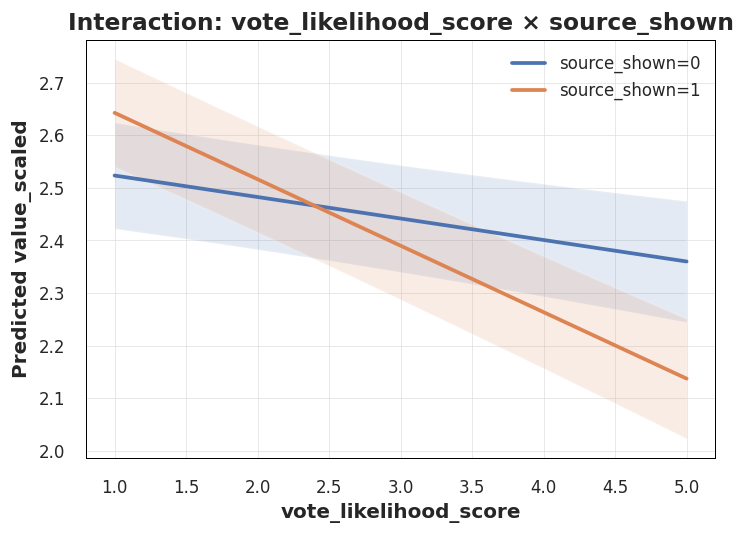

In [85]:
# # 2) vote × source_shown (H3)
m = fitted_models['stellingen.misinformation'][4]  # model with source_shown * vote_likelihood_score
filt = df[df['variable'] == 'stellingen.misinformation'].copy()
plot_interaction_continuous_by_binary(m, filt, x='vote_likelihood_score', moderator='source_shown')
plt.show()

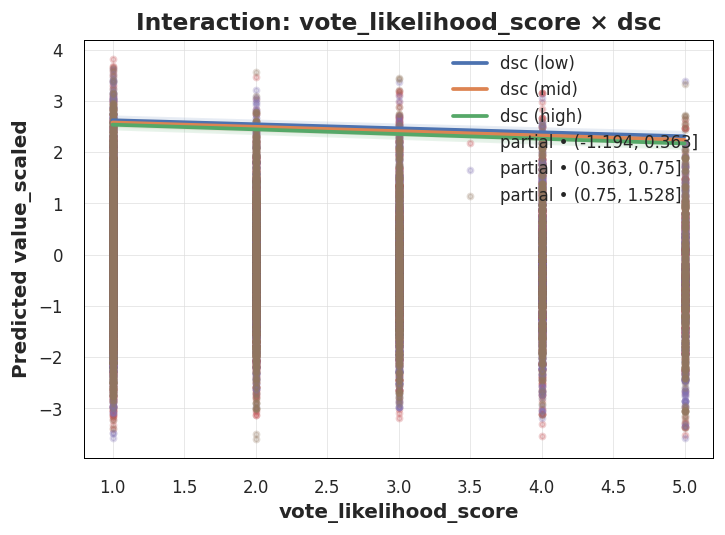

In [86]:
m = fitted_models['stellingen.misinformation'][3]  # model with vote_likelihood_score * dsc
filt = df[df['variable'] == 'stellingen.misinformation'].copy()
ax = plot_interaction_continuous_by_continuous(m, filt, x='vote_likelihood_score', moderator='dsc')
# # optional: overlay partial residuals
add_partial_residuals(ax, m, filt, x='vote_likelihood_score', moderator='dsc', bins=3)
plt.show()

In [395]:
import pandas as pd

df = pd.read_parquet("/home/akroon/webdav/ASCOR-FMG-4394-AnNoBias (Projectfolder)/data/final_merged_dataset_for_analysis.parquet")
# Print original number of rows
print("Before filtering:", len(df))

Before filtering: 153674


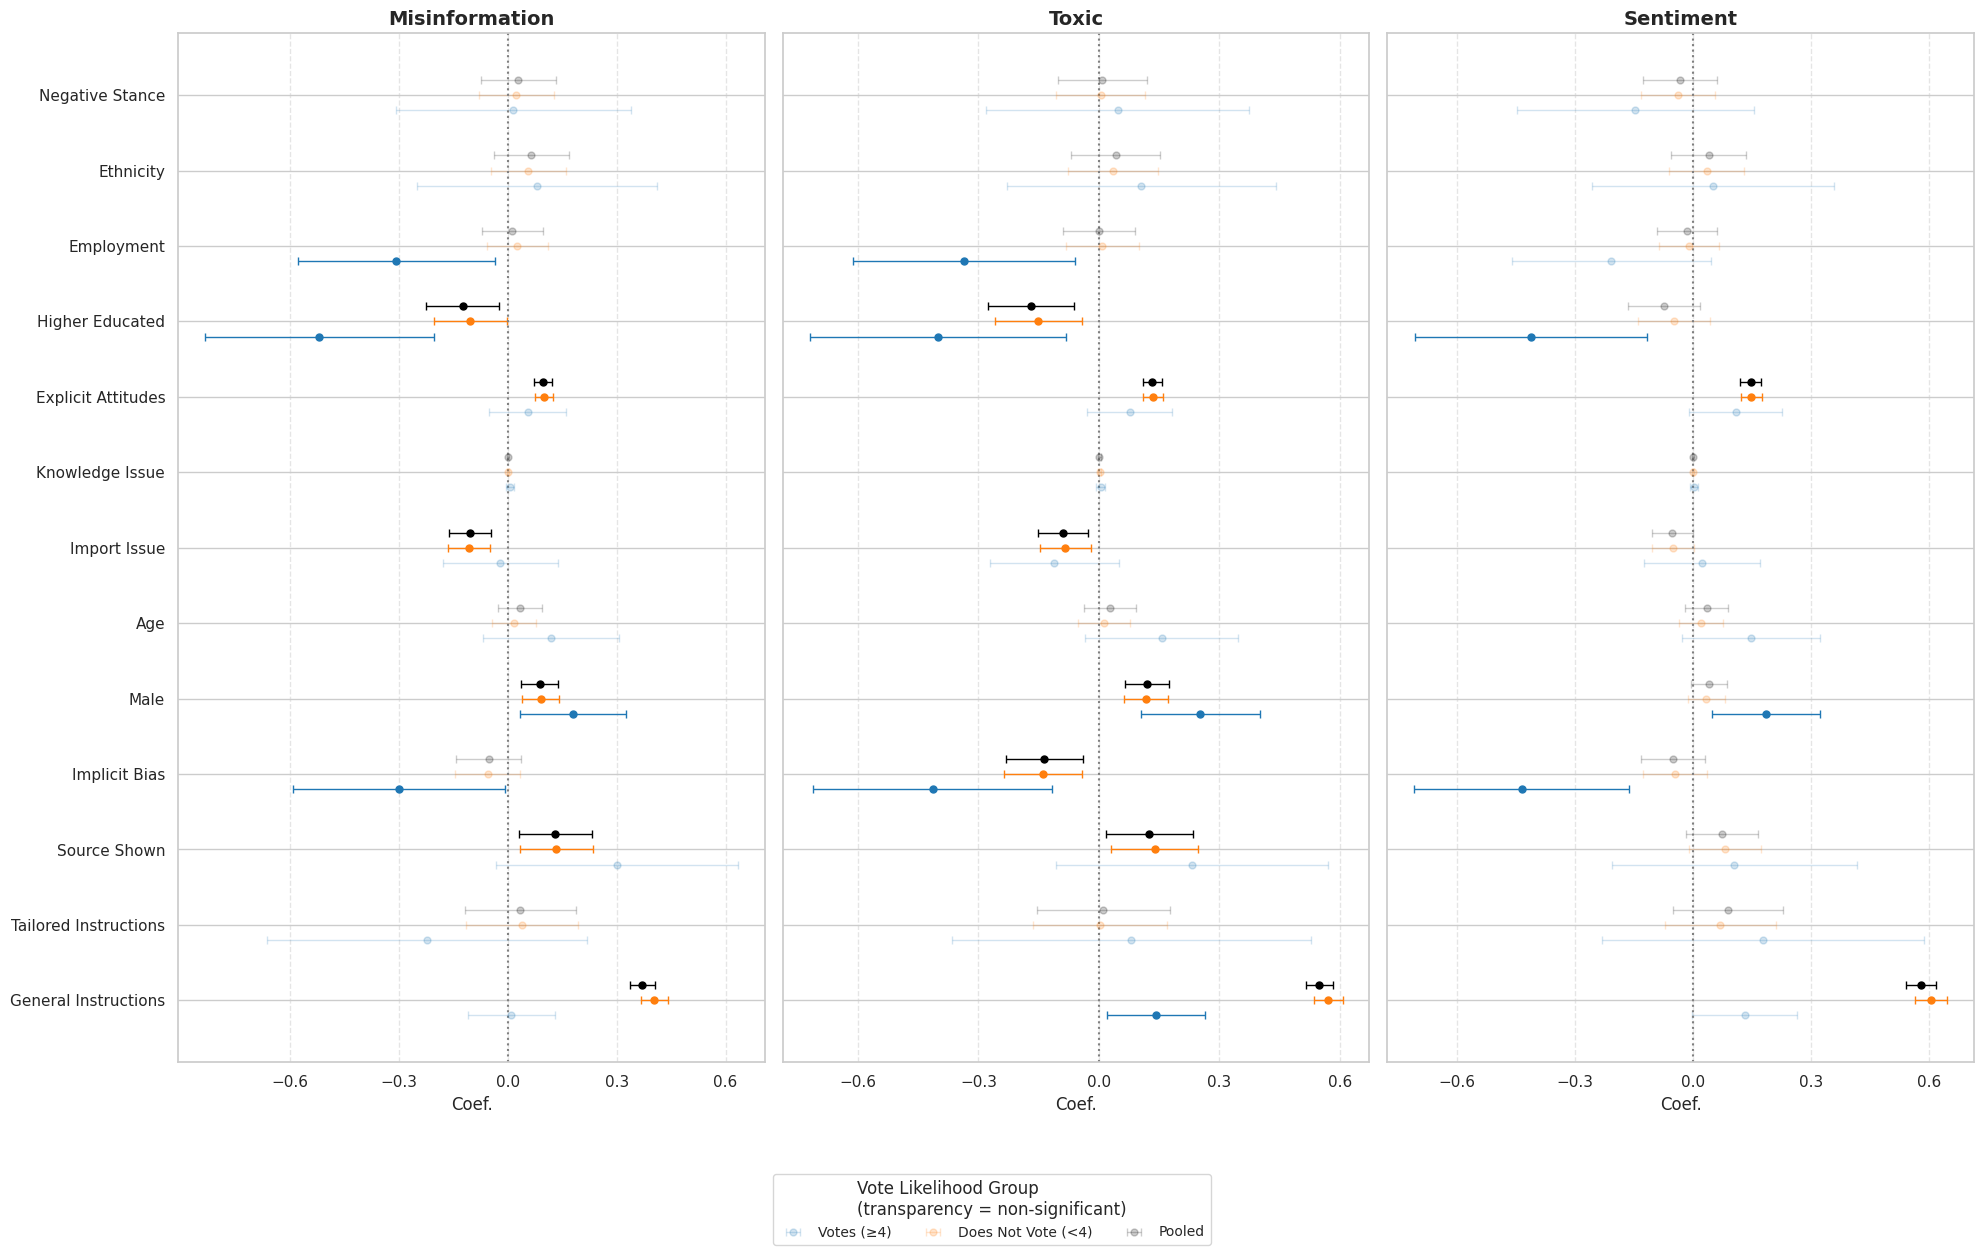

In [404]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Reinitialize df if needed
# df = pd.read_parquet("your_parquet_file_path_here")

# Step 1: Define grouping and predictors
df['vote_group'] = df['vote_likelihood_score'].apply(lambda x: 'Votes (≥4)' if x >= 5 else 'Does Not Vote (<4)')
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
desired_predictors = [
    'instruction_type[T.general instructions]', 'instruction_type[T.tailored instructions]',
    'source_shown', 'dsc', 'Male', 'Age', 'ImportIssue_1_numeric',
    'KnowIssue_1_numeric', 'AttitudeExtr2_combined', 'Edu_binary',
    'Werk_binair', 'Etniciteit_binair', 'negative_stance'
]

# Clean labels for plotting
label_map_ordered = [
    ('instruction_type[T.general instructions]', 'General Instructions'),
    ('instruction_type[T.tailored instructions]', 'Tailored Instructions'),
    ('source_shown', 'Source Shown'),
    ('dsc', 'Implicit Bias'),
    ('Male', 'Male'),
    ('Age', 'Age'),
    ('ImportIssue_1_numeric', 'Import Issue'),
    ('KnowIssue_1_numeric', 'Knowledge Issue'),
    ('AttitudeExtr2_combined', 'Explicit Attitudes'),
    ('Edu_binary', 'Higher Educated'),
    ('Werk_binair', 'Employment'),
    ('Etniciteit_binair', 'Ethnicity'),
    ('negative_stance', 'Negative Stance')
]
label_map = dict(label_map_ordered)
predictor_order = [v for _, v in label_map_ordered]

# Step 2: Fit models and extract results
plot_data = []

for var in variables:
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        if group == 'Pooled':
            subset = df[df['variable'] == var].copy()
        else:
            subset = df[(df['variable'] == var) & (df['vote_group'] == group)].copy()

        subset['instruction_type'] = pd.Categorical(
            subset['instruction_type'],
            categories=['no instructions', 'general instructions', 'tailored instructions'],
            ordered=True
        )

        formula = "value_scaled ~ instruction_type + source_shown + dsc + Male + Age + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + negative_stance"

        try:
            model = smf.mixedlm(formula, data=subset, groups=subset["uid"]).fit()
            for predictor in model.params.index:
                if predictor in desired_predictors:
                    est = model.params[predictor]
                    se = model.bse[predictor]
                    pval = model.pvalues[predictor]
                    plot_data.append({
                        "dv": var,
                        "group": group,
                        "predictor": predictor,
                        "predictor_clean": label_map[predictor],
                        "estimate": est,
                        "ci_lower": est - 1.96 * se,
                        "ci_upper": est + 1.96 * se,
                        "significant": pval < 0.05
                    })
        except Exception as e:
            print(f"⚠️ Model failed for {var} ({group}): {e}")

# Step 3: Format results for plotting
plot_df = pd.DataFrame(plot_data)
plot_df['predictor_order'] = plot_df['predictor_clean'].apply(lambda x: predictor_order.index(x))
plot_df['offset'] = plot_df['group'].map({'Votes (≥4)': 0.2, 'Does Not Vote (<4)': 0.0, 'Pooled': -0.2})
plot_df['y'] = plot_df['predictor_order'] + plot_df['offset']
plot_df['color'] = plot_df['group'].map({'Votes (≥4)': '#1f77b4', 'Does Not Vote (<4)': '#ff7f0e', 'Pooled': '#000000'})

# Re-plot with corrected order
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)
dvs_clean = ['Misinformation', 'Toxic', 'Sentiment']

for i, dv in enumerate(variables):
    ax = axes[i]
    subset = plot_df[plot_df['dv'] == dv]
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        gdata = subset[subset['group'] == group]
        for _, row in gdata.iterrows():
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=group if (i == 0 and row['predictor_order'] == 0) else None
            )
    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dvs_clean[i], fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()
    ax.set_yticks(range(len(predictor_order)))
    ax.set_yticklabels(list(reversed(predictor_order)), fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vote Likelihood Group\n(transparency = non-significant)",
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()



``` 

✅ Instructions Lead to More Problem Labeling — Especially Among Voters
General and Tailored Instructions are associated with increased labeling of tweets as misinformative, toxic, and negative — particularly in the Misinformation panel.

This effect is strongest among voters and the pooled sample, but mostly absent or weaker among non-voters.

📌 Interpretation: Instructions make engaged annotators more attentive to problematic content, increasing their threshold for labeling tweets as such. Less engaged annotators don't apply the guidelines effectively.

Implicit Bias Reduces Problem Detection
For Misinformation and Toxicity, higher implicit bias (dsc) is associated with lower labeling of problematic content — i.e., they miss problematic tweets.

📌 Interpretation: Annotators with higher implicit bias may downplay or overlook harm, or interpret content more leniently, reducing the likelihood of assigning problem labels.


Source Visibility Makes Annotators Stricter
Particularly in Misinformation, seeing the source significantly increases the chance of calling content misinformative.

📌 Interpretation: When a known source is shown, annotators apply stricter judgments — possibly due to preconceived credibility expectations or heightened scrutiny.


🧠 Explicit Attitudes and Issue Involvement Matter
Annotators with stronger issue attitudes (explicit) are more likely to label content as toxic, misinformative, or negative.

This suggests motivated processing — people with clear views are more sensitive to violations and judge more harshly.
``` 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Step 1: Define grouping and predictors
df['vote_group'] = df['vote_likelihood_score'].apply(lambda x: 'Votes (≥4)' if x >= 4 else 'Does Not Vote (<4)')
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']
desired_predictors = [
    'instruction_type[T.general instructions]', 'instruction_type[T.tailored instructions]',
    'source_shown', 'dsc', 'Male', 'Age', 'ImportIssue_1_numeric',
    'KnowIssue_1_numeric', 'AttitudeExtr2_combined', 'Edu_binary',
    'Werk_binair', 'Etniciteit_binair', 'negative_stance'
]


# Clean labels for plotting
label_map_ordered = [
    ('instruction_type[T.general instructions]', 'General Instructions'),
    ('instruction_type[T.tailored instructions]', 'Tailored Instructions'),
    ('source_shown', 'Source Shown'),
    ('dsc', 'Implicit Bias'),
    ('Male', 'Male'),
    ('Age', 'Age'),
    ('ImportIssue_1_numeric', 'Import Issue'),
    ('KnowIssue_1_numeric', 'Knowledge Issue'),
    ('AttitudeExtr2_combined', 'Explicit Attitudes'),
    ('Edu_binary', 'Higher Educated'),
    ('Werk_binair', 'Employment'),
    ('Etniciteit_binair', 'Ethnicity'),
    ('negative_stance', 'Negative Stance')
]
label_map = dict(label_map_ordered)
predictor_order = [v for _, v in label_map_ordered]

# Step 2: Fit models and extract results
plot_data = []

for var in variables:
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        if group == 'Pooled':
            subset = df[df['variable'] == var].copy()
        else:
            subset = df[(df['variable'] == var) & (df['vote_group'] == group)].copy()

        subset['instruction_type'] = pd.Categorical(
            subset['instruction_type'],
            categories=['no instructions', 'general instructions', 'tailored instructions'],
            ordered=True
        )

        formula = "value_scaled ~ instruction_type + source_shown + dsc + Male + Age + ImportIssue_1_numeric + KnowIssue_1_numeric + AttitudeExtr2_combined + Edu_binary + Werk_binair + Etniciteit_binair + negative_stance"

        
        try:
            model = smf.mixedlm(formula, data=subset, groups=subset["uid"]).fit()
            for predictor in model.params.index:
                if predictor in desired_predictors:
                    est = model.params[predictor]
                    se = model.bse[predictor]
                    pval = model.pvalues[predictor]
                    plot_data.append({
                        "dv": var,
                        "group": group,
                        "predictor": predictor,
                        "predictor_clean": label_map[predictor],
                        "estimate": est,
                        "ci_lower": est - 1.96 * se,
                        "ci_upper": est + 1.96 * se,
                        "significant": pval < 0.05
                    })
        except Exception as e:
            print(f"⚠️ Model failed for {var} ({group}): {e}")

# Step 3: Format results for plotting
plot_df['predictor_clean'] = plot_df['predictor'].map(label_map)
plot_df = plot_df[plot_df['predictor_clean'].isin(predictor_order)].copy()
plot_df['predictor_order'] = plot_df['predictor_clean'].apply(lambda x: predictor_order.index(x))
plot_df['y'] = plot_df['predictor_order'] + plot_df['offset']

# Re-plot with corrected order
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharey=True)
dvs_clean = ['Misinformation', 'Toxic', 'Sentiment']

for i, dv in enumerate(variables):
    ax = axes[i]
    subset = plot_df[plot_df['dv'] == dv]
    for group in ['Votes (≥4)', 'Does Not Vote (<4)', 'Pooled']:
        gdata = subset[subset['group'] == group]
        for _, row in gdata.iterrows():
            ax.errorbar(
                row['estimate'], row['y'],
                xerr=[[row['estimate'] - row['ci_lower']], [row['ci_upper'] - row['estimate']]],
                fmt='o',
                color=row['color'],
                alpha=1.0 if row['significant'] else 0.2,
                capsize=3, markersize=5, elinewidth=1,
                label=group if (i == 0 and row['predictor_order'] == 0) else None
            )
    ax.axvline(x=0, color='gray', linestyle='dotted')
    ax.set_title(dvs_clean[i], fontsize=14, weight='bold')
    ax.set_xticks(np.round(np.linspace(-0.6, 0.6, 5), 2))
    ax.set_xlabel("Coef.", fontsize=12)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.invert_yaxis()
    ax.set_yticks(range(len(predictor_order)))
    ax.set_yticklabels(list(reversed(predictor_order)), fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Vote Likelihood Group\n(transparency = non-significant)",
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


<ggplot: (1000 x 800)>


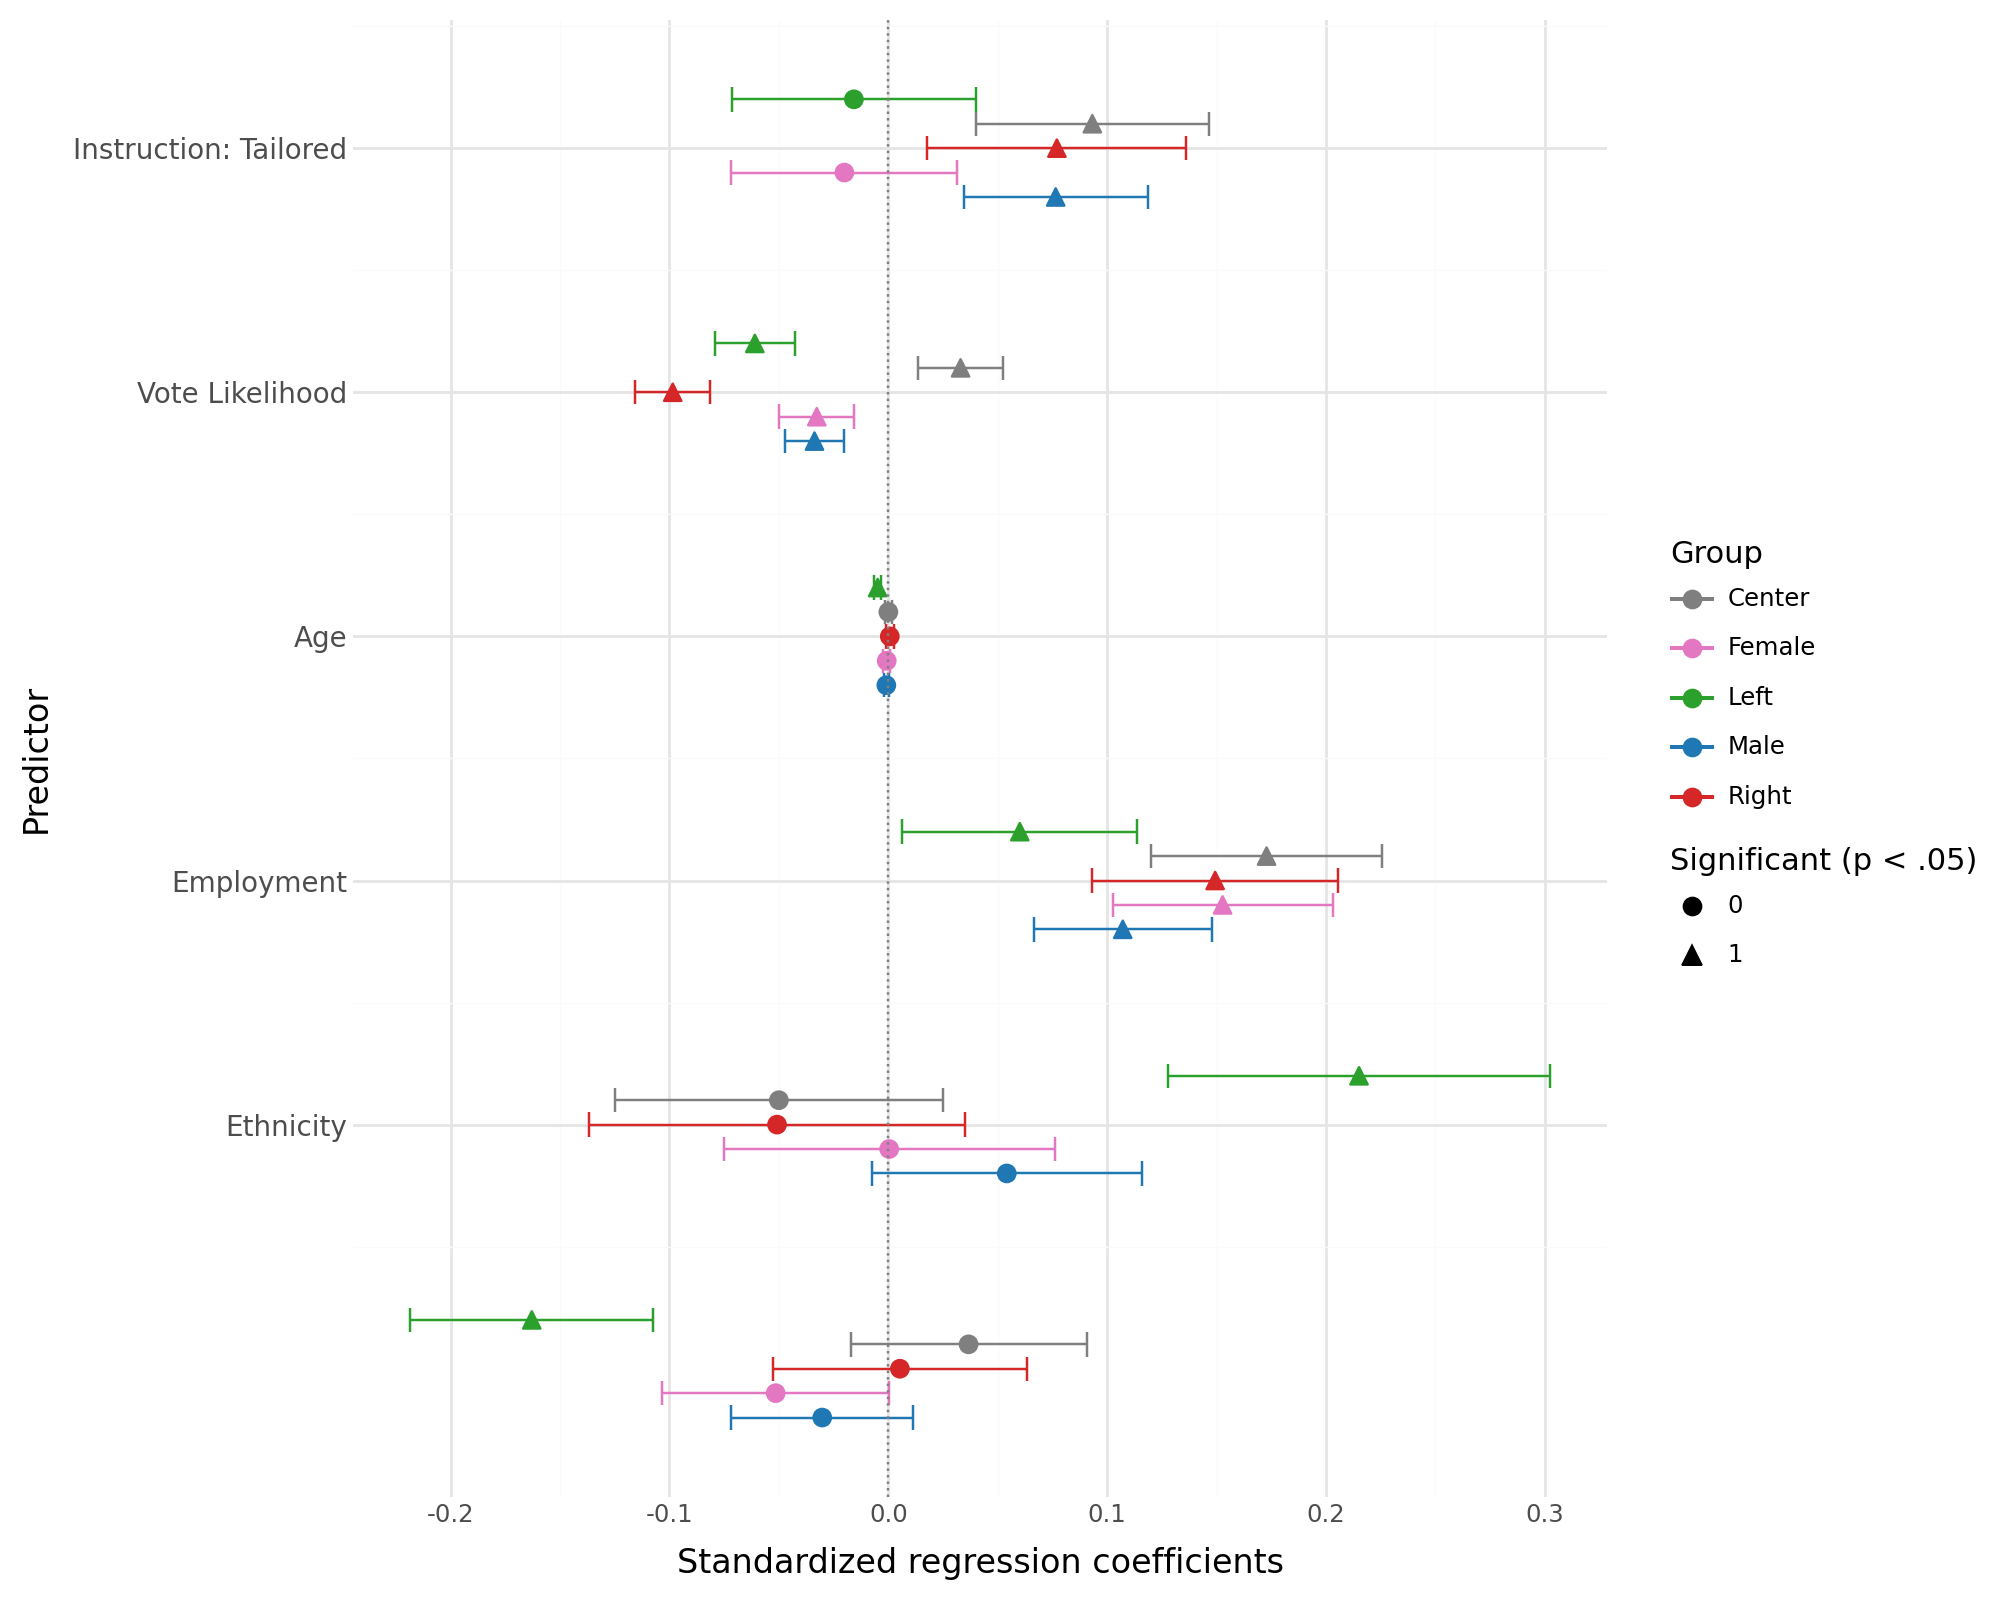

In [99]:
import pandas as pd
import statsmodels.formula.api as smf
from plotnine import (
    ggplot, aes, geom_point, geom_errorbarh, geom_vline,
    labs, theme_minimal, theme, element_text,
    scale_color_manual, scale_y_continuous
)

# --- Step 1: Data preparation as before ---

df_sub = df[df['variable'] == 'stellingen.misinformation'].copy()

predictors = ['Age', 'vote_likelihood_score', 'C(instruction_type)', 'Etniciteit_binair', 'Werk_binair']
formula = 'value_scaled ~ ' + ' + '.join(predictors)

# Models by Ideology_Group
models_ideo, infos_ideo = [], []
for ideology, group_data in df_sub.groupby('Ideology_Group'):
    if len(group_data) < 50:
        continue
    try:
        model = smf.ols(formula, data=group_data).fit()
        models_ideo.append(model)
        infos_ideo.append(ideology)
    except Exception as e:
        print(f"Error for ideology {ideology}: {e}")

# Models by Gender
models_gender, infos_gender = [], []
for male, group_data in df_sub.groupby('Male'):
    if len(group_data) < 50:
        continue
    try:
        model = smf.ols(formula, data=group_data).fit()
        infos_gender.append('Male' if male == 1 else 'Female')
        models_gender.append(model)
    except Exception as e:
        print(f"Error for gender {male}: {e}")

# Extract results
def extract_results(models, infos, group_type):
    rows = []
    for model, group in zip(models, infos):
        for predictor in model.params.index:
            if predictor == "Intercept":
                continue
            est = model.params[predictor]
            se = model.bse[predictor]
            ci_lower = est - 1.96 * se
            ci_upper = est + 1.96 * se
            p = model.pvalues[predictor]
            sig = int(p < 0.05)
            rows.append({
                'predictor': predictor,
                'estimate': est,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'p_value': p,
                'significant': str(sig),
                'Group': group,
                'Group_Type': group_type
            })
    return pd.DataFrame(rows)

df_ideo = extract_results(models_ideo, infos_ideo, 'Ideology')
df_gender = extract_results(models_gender, infos_gender, 'Gender')
df_combined = pd.concat([df_ideo, df_gender], ignore_index=True)

# Clean labels
var_map = {
    'C(instruction_type)[T.general instructions]': 'Instruction: General',
    'C(instruction_type)[T.tailored instructions]': 'Instruction: Tailored',
    'vote_likelihood_score': 'Vote Likelihood',
    'Age': 'Age',
    'Werk_binair': 'Employment',
    'Etniciteit_binair': 'Ethnicity'
}
df_combined['predictor_label'] = df_combined['predictor'].map(var_map).fillna(df_combined['predictor'])

# Set order
predictors_order = list(reversed(var_map.values()))
df_combined['predictor_label'] = pd.Categorical(df_combined['predictor_label'],
                                                categories=predictors_order,
                                                ordered=True)

# Assign numeric y-position for each predictor
predictor_to_index = {label: i for i, label in enumerate(predictors_order)}
# Convert categorical predictor label to integer y position
df_combined['y_base'] = df_combined['predictor_label'].cat.codes

# Apply group vertical offsets
group_offsets = {
    'Left':  0.20,
    'Center': 0.10,
    'Right': 0.00,
    'Female': -0.10,
    'Male': -0.20
}
df_combined['Group_Offset'] = df_combined['Group'].map(group_offsets)
df_combined['y'] = df_combined['y_base'] + df_combined['Group_Offset']

# Color mapping
color_map = {
    'Left': '#2ca02c',     # green
    'Center': '#7f7f7f',   # grey
    'Right': '#d62728',    # red
    'Female': '#e377c2',   # pink
    'Male': '#1f77b4'      # blue
}

# Reverse y-axis labels so top = first item
y_labels = {i: label for label, i in predictor_to_index.items()}

# --- Final Plot ---
p = (
    ggplot(df_combined, aes(x='estimate', y='y', color='Group'))
    + geom_point(aes(shape='significant'), size=3)
    + geom_errorbarh(aes(xmin='ci_lower', xmax='ci_upper'), height=0.1, size=0.5)
    + geom_vline(xintercept=0, linetype='dotted', color='gray')
    + scale_color_manual(values=color_map)
    + scale_y_continuous(
        breaks=list(predictor_to_index.values()),
        labels=[y_labels[i] for i in predictor_to_index.values()]
    )
    + labs(
        x='Standardized regression coefficients',
        y='Predictor',
        color='Group',
        shape='Significant (p < .05)'
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 8),
        axis_text_y=element_text(size=10),
        axis_title=element_text(size=12),
        legend_position='right'
    )
)

print(p)
p